# 04 - Boosting Models with Controlled Validation

This notebook continues after the ExtraTrees baseline. The goal is to compare stronger boosting models while keeping the same controlled evaluation strategy.

We evaluate:
- `ExtraTreesRegressor` as the robust baseline reference
- `HistGradientBoostingRegressor` from scikit-learn
- `XGBRegressor` if `xgboost` is installed
- `LGBMRegressor` if `lightgbm` is installed
- `CatBoostRegressor` if `catboost` is installed

The focus is not only global MAE/RMSE/R². We also evaluate target-specific feature sets, gravity-regime errors, stress slices, near inverse-design zone performance, and feasibility metrics for the constraints: `96 <= P80 <= 101` and `R95 <= 175`.

## 1. Imports and Project Paths

In [4]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for path in [SUBMISSIONS_DIR, MODELS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)
print("Inverse design directory:", INVERSE_DIR)
print("Submissions directory:", SUBMISSIONS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Inverse design directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design
Submissions directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions


## 2. Load Data and Challenge Constraints

The constraints file is essential for inverse design. In this notebook it is also used to evaluate whether the models are reliable near the target feasibility zone.

In [5]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor"
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize"
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]
submission_template = pd.read_csv(FORWARD_DIR / "prediction_submission_template.csv")

constraints_path = INVERSE_DIR / "constraints.json"
if not constraints_path.exists():
    constraints_path = PROJECT_ROOT / "constraints.json"

with open(constraints_path, "r") as f:
    constraints_data = json.load(f)

output_constraints = constraints_data["constraints"]
input_bounds = constraints_data["input_bounds"]

print("Raw train:", raw_train.shape)
print("Raw test:", raw_test.shape)
print("Targets:", y.shape)
print("Constraints path:", constraints_path)

display(pd.DataFrame([output_constraints]))
display(pd.DataFrame(input_bounds).T)

Raw train: (2930, 8)
Raw test: (492, 8)
Targets: (2930, 6)
Constraints path: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design/constraints.json


,p80_min,p80_max,r95_max
0,96.0,101.0,175.0


,min,max
energy,0.500000,5.000000
angle_rad,0.261799,1.570796
coupling,0.200000,1.700000
strength,0.400000,4.200000
porosity,0.000000,0.330000
gravity,1.020000,10.470000
atmosphere,0.000000,1.000000
shape_factor,0.700000,1.500000


## 3. Physics-Inspired Feature Engineering

The features below are proxies, not exact physical equations. The dataset does not include projectile mass, diameter, velocity, explicit material class, or impact location.

In [6]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])
    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
    X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
    X["fragility"] = X["porosity"] / (X["strength"] + eps)
    X["range_proxy"] = (X["effective_energy"] * (X["cos_angle"] ** 2)) / (X["gravity"] * X["strength"] + eps)
    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    return X

X_fe_train = add_physics_features(raw_train)
X_fe_test = add_physics_features(raw_test)

print("X_fe_train:", X_fe_train.shape)
print("X_fe_test:", X_fe_test.shape)

def check_modeling_matrix(X: pd.DataFrame, name: str):
    numeric = X.select_dtypes(include=[np.number])

    print(f"\n{name}")
    print("Shape:", X.shape)
    print("Missing:", int(X.isna().sum().sum()))
    print("Infinite:", int(np.isinf(numeric).sum().sum()))
    print("Non-numeric:", [c for c in X.columns if c not in numeric.columns])

check_modeling_matrix(X_fe_train, "X_fe_train")
check_modeling_matrix(X_fe_test, "X_fe_test")

X_fe_train: (2930, 48)
X_fe_test: (492, 48)

X_fe_train
Shape: (2930, 48)
Missing: 0
Infinite: 0
Non-numeric: []

X_fe_test
Shape: (492, 48)
Missing: 0
Infinite: 0
Non-numeric: []


## 4. Feature Sets

In [7]:
raw_features = input_cols.copy()

core_physics_features = raw_features + [
    "effective_energy", "log_energy", "log_effective_energy", "sin_angle", "cos_angle", "tan_angle",
    "horizontal_energy", "vertical_energy", "vertical_horizontal_ratio",
    "energy_per_strength", "effective_energy_per_strength", "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "energy_per_gravity", "effective_energy_per_gravity", "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
]

extended_physics_features = core_physics_features + [
    "pi_gravity_proxy", "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility", "range_proxy",
    "energy_sin_angle", "momentum_proxy", "coupling_per_atm_clipped", "log_coupling_per_atm", "retention_factor",
]

regime_features = extended_physics_features + ["porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo"]

fragmentation_features = raw_features + [
    "effective_energy", "log_effective_energy", "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength", "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength", "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility", "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

distance_features = raw_features + [
    "effective_energy", "log_effective_energy", "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity", "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy", "scaled_energy", "range_proxy", "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

def clean_feature_list(features, X):
    seen, out = set(), []
    for f in features:
        if f in X.columns and f not in seen:
            out.append(f)
            seen.add(f)
    return out

core_physics_features = clean_feature_list(core_physics_features, X_fe_train)
extended_physics_features = clean_feature_list(extended_physics_features, X_fe_train)
regime_features = clean_feature_list(regime_features, X_fe_train)
fragmentation_features = clean_feature_list(fragmentation_features, X_fe_train)
distance_features = clean_feature_list(distance_features, X_fe_train)
full_features = X_fe_train.columns.tolist()

feature_sets = {
    "raw": raw_features,
    "core_physics": core_physics_features,
    "extended_physics": extended_physics_features,
    "extended_plus_regimes": regime_features,
    "full_features": full_features,
    "target_family_specific": None,
}

def target_family_feature_selector(target):
    return fragmentation_features if target in fragmentation_targets else distance_features

display(pd.DataFrame([
    {"feature_set": k, "n_features": "target-dependent" if v is None else len(v)}
    for k, v in feature_sets.items()
]))

,feature_set,n_features
0,raw,8
1,core_physics,32
2,extended_physics,43
3,extended_plus_regimes,48
4,full_features,48
5,target_family_specific,target-dependent


## 5. Metrics

In [8]:
def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    out = {"MAE": mae, "RMSE": rmse, "R2": r2}
    if target_name is not None:
        out["normalized_MAE"] = mae / (y[target_name].std() + 1e-9)
    return out

def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)

p80_min = output_constraints["p80_min"]
p80_max = output_constraints["p80_max"]
r95_max = output_constraints["r95_max"]

def feasibility_mask(df_targets):
    return (df_targets["P80"].between(p80_min, p80_max)) & (df_targets["R95"] <= r95_max)

def near_feasible_mask(df_targets):
    return (df_targets["P80"].between(80, 120)) & (df_targets["R95"] <= 250)

def constraint_violation_score(df_pred):
    p80_low = np.maximum(p80_min - df_pred["P80"], 0)
    p80_high = np.maximum(df_pred["P80"] - p80_max, 0)
    r95_violation = np.maximum(df_pred["R95"] - r95_max, 0)
    return p80_low + p80_high + r95_violation

def custom_constraint_metrics(y_true_df, y_pred_df):
    true_feasible = feasibility_mask(y_true_df)
    pred_feasible = feasibility_mask(y_pred_df)
    near_zone = near_feasible_mask(y_true_df)
    tp = int((true_feasible & pred_feasible).sum())
    fp = int((~true_feasible & pred_feasible).sum())
    fn = int((true_feasible & ~pred_feasible).sum())
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    violation = constraint_violation_score(y_pred_df)
    metrics = {
        "n_true_feasible": int(true_feasible.sum()),
        "n_pred_feasible": int(pred_feasible.sum()),
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "feasible_precision": precision,
        "feasible_recall": recall,
        "feasible_f1": f1,
        "mean_pred_constraint_violation": float(violation.mean()),
        "median_pred_constraint_violation": float(np.median(violation)),
        "near_zone_count": int(near_zone.sum()),
    }
    if near_zone.sum() > 0:
        metrics["near_zone_MAE_P80"] = mean_absolute_error(y_true_df.loc[near_zone, "P80"], y_pred_df.loc[near_zone, "P80"])
        metrics["near_zone_MAE_R95"] = mean_absolute_error(y_true_df.loc[near_zone, "R95"], y_pred_df.loc[near_zone, "R95"])
        metrics["near_zone_R95_bias"] = float((y_pred_df.loc[near_zone, "R95"] - y_true_df.loc[near_zone, "R95"]).mean())
    return metrics

## 6. Model Builders

In [9]:
AVAILABLE_MODELS = {}

def build_extratrees(random_state=42):
    return ExtraTreesRegressor(n_estimators=800, max_features="sqrt", min_samples_leaf=2, random_state=random_state, n_jobs=-1)
AVAILABLE_MODELS["ExtraTrees"] = build_extratrees

def build_histgb(random_state=42):
    return HistGradientBoostingRegressor(loss="squared_error", learning_rate=0.05, max_iter=500, max_leaf_nodes=31, min_samples_leaf=20, l2_regularization=0.05, random_state=random_state)
AVAILABLE_MODELS["HistGradientBoosting"] = build_histgb

try:
    from xgboost import XGBRegressor
    def build_xgb(random_state=42):
        return XGBRegressor(n_estimators=900, learning_rate=0.03, max_depth=4, min_child_weight=2, subsample=0.85, colsample_bytree=0.85, reg_alpha=0.05, reg_lambda=2.0, objective="reg:squarederror", random_state=random_state, n_jobs=-1)
    AVAILABLE_MODELS["XGBoost"] = build_xgb
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMRegressor
    def build_lgbm(random_state=42):
        return LGBMRegressor(n_estimators=1200, learning_rate=0.025, num_leaves=31, min_child_samples=20, subsample=0.85, colsample_bytree=0.85, reg_alpha=0.05, reg_lambda=2.0, random_state=random_state, n_jobs=-1, verbosity=-1)
    AVAILABLE_MODELS["LightGBM"] = build_lgbm
except Exception as e:
    print("LightGBM unavailable:", e)

try:
    from catboost import CatBoostRegressor
    def build_catboost(random_state=42):
        return CatBoostRegressor(iterations=1200, learning_rate=0.03, depth=6, l2_leaf_reg=5.0, loss_function="RMSE", random_seed=random_state, verbose=False)
    AVAILABLE_MODELS["CatBoost"] = build_catboost
except Exception as e:
    print("CatBoost unavailable:", e)

print("Available models:", list(AVAILABLE_MODELS.keys()))

Available models: ['ExtraTrees', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


## 7. Cross-Validation Functions

In [10]:
def get_features_for_feature_set(feature_set_name, target):
    if feature_set_name == "target_family_specific":
        return target_family_feature_selector(target)
    return feature_sets[feature_set_name]

def cross_validate_one_target(X, y_df, target, features, model_name, model_builder, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    oof_pred = np.zeros(len(y_df))
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):
        X_train = X.iloc[train_idx][features]
        X_valid = X.iloc[valid_idx][features]
        y_train = y_df.iloc[train_idx][target]
        y_valid = y_df.iloc[valid_idx][target]
        model = model_builder(random_state=random_state + fold)
        model.fit(X_train, y_train)
        pred = clip_predictions(model.predict(X_valid), target)
        oof_pred[valid_idx] = pred
        metrics = regression_metrics(y_valid, pred, target_name=target)
        metrics.update({"fold": fold, "target": target, "model": model_name, "n_features": len(features)})
        fold_results.append(metrics)
    fold_df = pd.DataFrame(fold_results)
    overall = regression_metrics(y_df[target], oof_pred, target_name=target)
    overall.update({"fold": "OOF", "target": target, "model": model_name, "n_features": len(features)})
    return fold_df, overall, oof_pred

def evaluate_model_feature_set(model_name, model_builder, feature_set_name, n_splits=5):
    overall_rows, fold_rows = [], []
    oof = pd.DataFrame(index=y.index)
    for target in target_cols:
        features = get_features_for_feature_set(feature_set_name, target)
        fold_df, overall, pred = cross_validate_one_target(X_fe_train, y, target, features, model_name, model_builder, n_splits=n_splits)
        fold_df["feature_set"] = feature_set_name
        overall["feature_set"] = feature_set_name
        fold_rows.append(fold_df)
        overall_rows.append(overall)
        oof[target] = pred
    overall_df = pd.DataFrame(overall_rows)
    fold_df = pd.concat(fold_rows, ignore_index=True)
    cmetrics = custom_constraint_metrics(y, oof)
    cmetrics.update({"model": model_name, "feature_set": feature_set_name})
    return overall_df, fold_df, oof, pd.DataFrame([cmetrics])

## 8. Evaluate Candidate Models and Feature Sets

This can take several minutes. Start with two feature sets, then expand later if needed.

In [11]:
feature_sets_to_evaluate = ["target_family_specific", "extended_plus_regimes"]

all_overall, all_folds, constraint_rows = [], [], []
oof_store = {}

for model_name, builder in AVAILABLE_MODELS.items():
    for feature_set_name in feature_sets_to_evaluate:
        print(f"Evaluating {model_name} with {feature_set_name}...")
        overall_df, fold_df, oof_df, constraint_df = evaluate_model_feature_set(model_name, builder, feature_set_name, n_splits=5)
        all_overall.append(overall_df)
        all_folds.append(fold_df)
        constraint_rows.append(constraint_df)
        oof_store[(model_name, feature_set_name)] = oof_df

boosting_results = pd.concat(all_overall, ignore_index=True)
boosting_folds = pd.concat(all_folds, ignore_index=True)
constraint_eval = pd.concat(constraint_rows, ignore_index=True)

display(boosting_results.sort_values(["target", "normalized_MAE"]))
display(constraint_eval.sort_values("feasible_f1", ascending=False))

Evaluating ExtraTrees with target_family_specific...
Evaluating ExtraTrees with extended_plus_regimes...
Evaluating HistGradientBoosting with target_family_specific...
Evaluating HistGradientBoosting with extended_plus_regimes...
Evaluating XGBoost with target_family_specific...
Evaluating XGBoost with extended_plus_regimes...
Evaluating LightGBM with target_family_specific...
Evaluating LightGBM with extended_plus_regimes...
Evaluating CatBoost with target_family_specific...
Evaluating CatBoost with extended_plus_regimes...


,MAE,RMSE,R2,normalized_MAE,fold,target,model,n_features,feature_set
0,7.711179,10.257217,0.975659,0.117271,OOF,P80,ExtraTrees,34,target_family_specific
48,7.771196,10.365824,0.975140,0.118184,OOF,P80,CatBoost,34,target_family_specific
6,7.790379,10.376451,0.975089,0.118475,OOF,P80,ExtraTrees,48,extended_plus_regimes
54,7.811224,10.407890,0.974938,0.118792,OOF,P80,CatBoost,48,extended_plus_regimes
24,7.893487,10.532602,0.974334,0.120043,OOF,P80,XGBoost,34,target_family_specific
30,7.896708,10.506842,0.974459,0.120092,OOF,P80,XGBoost,48,extended_plus_regimes
36,8.078723,10.800985,0.973009,0.122860,OOF,P80,LightGBM,34,target_family_specific
42,8.111756,10.829532,0.972866,0.123363,OOF,P80,LightGBM,48,extended_plus_regimes
12,8.115012,10.811319,0.972958,0.123412,OOF,P80,HistGradientBoosting,34,target_family_specific
18,8.152221,10.842439,0.972802,0.123978,OOF,P80,HistGradientBoosting,48,extended_plus_regimes


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,mean_pred_constraint_violation,median_pred_constraint_violation,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias,model,feature_set
1,35,37,13,24,22,0.351351,0.371429,0.361111,199.771844,135.670328,372,4.526658,25.229399,14.175167,ExtraTrees,extended_plus_regimes
0,35,39,13,26,22,0.333333,0.371429,0.351351,199.695516,135.196588,372,4.571787,25.516818,13.959853,ExtraTrees,target_family_specific
9,35,34,11,23,24,0.323529,0.314286,0.318841,200.336002,135.847683,372,4.704320,25.323286,14.005247,CatBoost,extended_plus_regimes
2,35,37,11,26,24,0.297297,0.314286,0.305556,201.057405,136.441135,372,4.793811,28.309669,16.038564,HistGradientBoosting,target_family_specific
8,35,37,11,26,24,0.297297,0.314286,0.305556,200.315906,135.483163,372,4.680717,25.034528,13.365765,CatBoost,target_family_specific
6,35,34,10,24,25,0.294118,0.285714,0.289855,200.507687,136.221180,372,4.765257,27.634249,15.542543,LightGBM,target_family_specific
4,35,36,10,26,25,0.277778,0.285714,0.281690,200.264157,136.321110,372,4.624071,25.781849,14.939968,XGBoost,target_family_specific
5,35,33,9,24,26,0.272727,0.257143,0.264706,200.482534,136.046486,372,4.671277,25.624563,14.781374,XGBoost,extended_plus_regimes
3,35,35,8,27,27,0.228571,0.228571,0.228571,201.292859,136.426528,372,4.847291,27.209578,15.014715,HistGradientBoosting,extended_plus_regimes
7,35,28,7,21,28,0.250000,0.200000,0.222222,200.715732,136.741794,372,4.842677,26.819608,14.095501,LightGBM,extended_plus_regimes


## 9. Select Best Model and Feature Set Per Target

In [12]:
best_target_rows = boosting_results.sort_values(["target", "normalized_MAE"]).groupby("target", as_index=False).first()
best_model_feature_by_target = {row["target"]: (row["model"], row["feature_set"]) for _, row in best_target_rows.iterrows()}

display(best_target_rows[["target", "model", "feature_set", "MAE", "RMSE", "R2", "normalized_MAE", "n_features"]])
print(best_model_feature_by_target)

selected_oof = pd.DataFrame(index=y.index)
for target in target_cols:
    model_name, feature_set_name = best_model_feature_by_target[target]
    selected_oof[target] = oof_store[(model_name, feature_set_name)][target]

selected_metrics = []
for target in target_cols:
    metrics = regression_metrics(y[target], selected_oof[target], target_name=target)
    metrics["target"] = target
    metrics["selected_model"] = best_model_feature_by_target[target][0]
    metrics["selected_feature_set"] = best_model_feature_by_target[target][1]
    selected_metrics.append(metrics)
selected_metrics_df = pd.DataFrame(selected_metrics)
display(selected_metrics_df.sort_values("normalized_MAE"))
display(pd.DataFrame([custom_constraint_metrics(y, selected_oof)]))

,target,model,feature_set,MAE,RMSE,R2,normalized_MAE,n_features
0,P80,ExtraTrees,target_family_specific,7.711179,10.257217,0.975659,0.117271,34
1,R50_fines,ExtraTrees,extended_plus_regimes,50.250298,78.434966,0.899044,0.203526,48
2,R50_oversize,ExtraTrees,extended_plus_regimes,22.549196,38.438910,0.874300,0.207947,48
3,R95,ExtraTrees,extended_plus_regimes,40.488282,66.977968,0.921136,0.169732,48
4,fines_frac,ExtraTrees,target_family_specific,0.006487,0.014240,0.956900,0.094558,34
5,oversize_frac,CatBoost,extended_plus_regimes,0.026033,0.035716,0.990267,0.071898,48


{'P80': ('ExtraTrees', 'target_family_specific'), 'R50_fines': ('ExtraTrees', 'extended_plus_regimes'), 'R50_oversize': ('ExtraTrees', 'extended_plus_regimes'), 'R95': ('ExtraTrees', 'extended_plus_regimes'), 'fines_frac': ('ExtraTrees', 'target_family_specific'), 'oversize_frac': ('CatBoost', 'extended_plus_regimes')}


,MAE,RMSE,R2,normalized_MAE,target,selected_model,selected_feature_set
2,0.026033,0.035716,0.990267,0.071898,oversize_frac,CatBoost,extended_plus_regimes
1,0.006487,0.014240,0.956900,0.094558,fines_frac,ExtraTrees,target_family_specific
0,7.711179,10.257217,0.975659,0.117271,P80,ExtraTrees,target_family_specific
3,40.488282,66.977968,0.921136,0.169732,R95,ExtraTrees,extended_plus_regimes
4,50.250298,78.434966,0.899044,0.203526,R50_fines,ExtraTrees,extended_plus_regimes
5,22.549196,38.438910,0.874300,0.207947,R50_oversize,ExtraTrees,extended_plus_regimes


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,mean_pred_constraint_violation,median_pred_constraint_violation,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias
0,35,39,13,26,22,0.333333,0.371429,0.351351,199.85991,135.846149,372,4.571787,25.229399,14.175167


## 10. Error Analysis by Target

,target,selected_model,selected_feature_set,MAE,Median_AE,P90_AE,P95_AE,Max_AE,Bias_mean_residual,R2
0,P80,ExtraTrees,target_family_specific,7.711179,5.946852,16.858204,21.748532,54.213116,-0.008502,0.975659
1,fines_frac,ExtraTrees,target_family_specific,0.006487,0.000635,0.019544,0.031649,0.158568,-0.000066,0.956900
2,oversize_frac,CatBoost,extended_plus_regimes,0.026033,0.019302,0.058786,0.077247,0.187102,0.000009,0.990267
3,R95,ExtraTrees,extended_plus_regimes,40.488282,20.826008,102.933259,149.215044,498.060737,-0.277394,0.921136
4,R50_fines,ExtraTrees,extended_plus_regimes,50.250298,27.138763,129.092999,175.049355,549.996096,-0.309918,0.899044
5,R50_oversize,ExtraTrees,extended_plus_regimes,22.549196,11.429620,55.926858,82.452303,348.671160,0.000712,0.874300


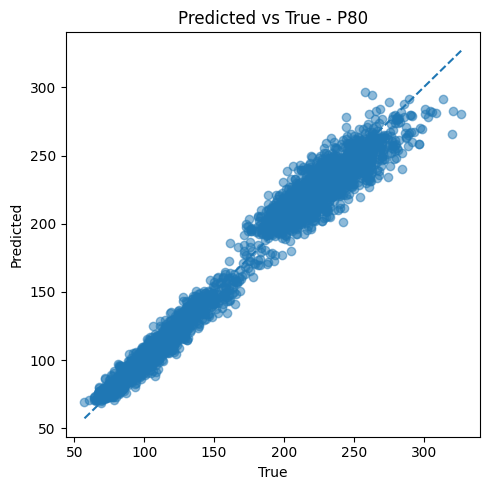

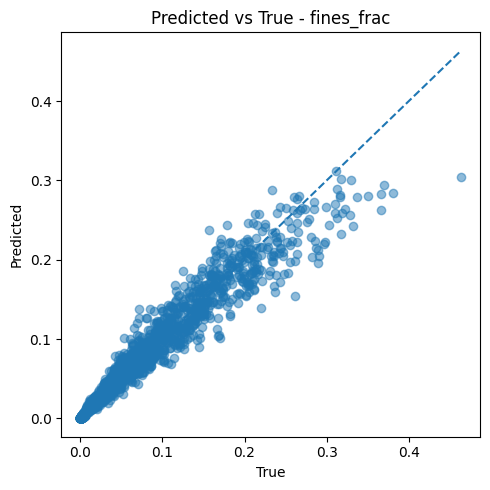

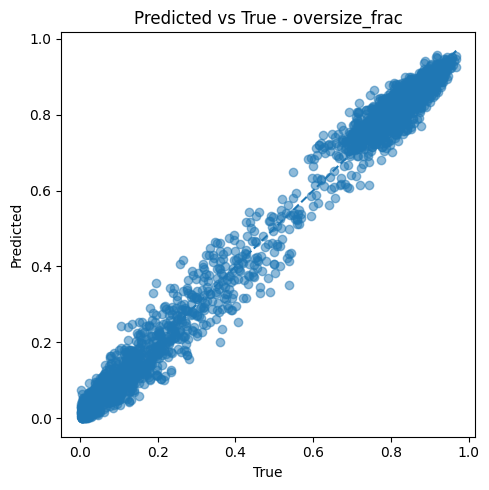

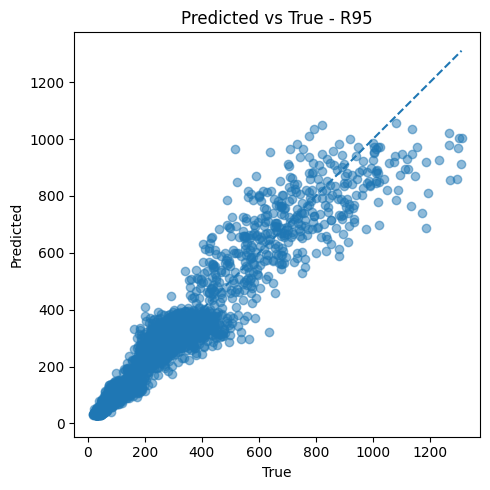

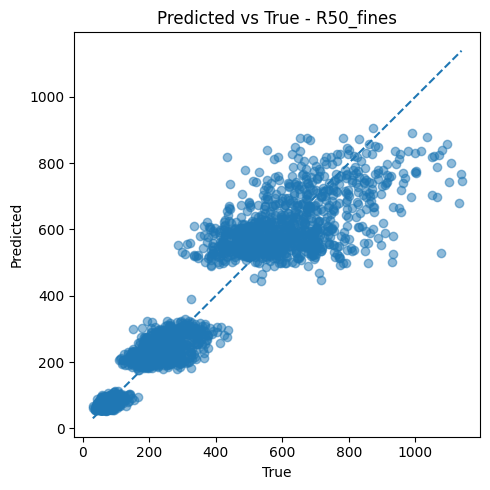

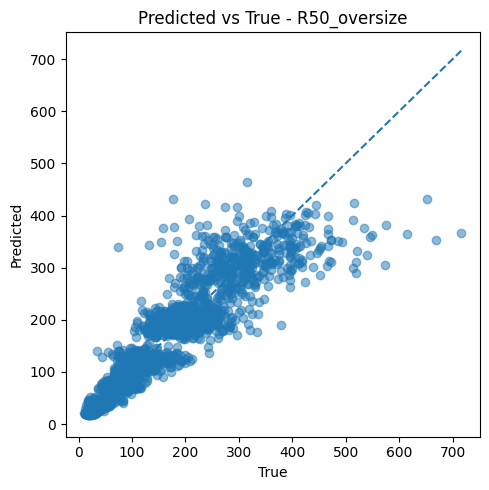

In [13]:
error_summary = []
for target in target_cols:
    residual = selected_oof[target] - y[target]
    abs_error = np.abs(residual)
    error_summary.append({
        "target": target,
        "selected_model": best_model_feature_by_target[target][0],
        "selected_feature_set": best_model_feature_by_target[target][1],
        "MAE": abs_error.mean(),
        "Median_AE": np.median(abs_error),
        "P90_AE": np.percentile(abs_error, 90),
        "P95_AE": np.percentile(abs_error, 95),
        "Max_AE": abs_error.max(),
        "Bias_mean_residual": residual.mean(),
        "R2": r2_score(y[target], selected_oof[target]),
    })
error_summary_df = pd.DataFrame(error_summary)
display(error_summary_df)

for target in target_cols:
    plt.figure(figsize=(5, 5))
    plt.scatter(y[target], selected_oof[target], alpha=0.5)
    min_val = min(y[target].min(), selected_oof[target].min())
    max_val = max(y[target].max(), selected_oof[target].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs True - {target}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

## 11. Gravity-Regime Evaluation

,gravity,n,MAE,Median_AE,true_mean,pred_mean,relative_MAE,target
0,1.62,990,7.514821,5.829020,172.057458,172.137717,0.043676,P80
1,3.71,1000,7.819317,6.139897,173.218872,173.091830,0.045141,P80
2,9.81,940,7.802943,6.025330,170.305048,170.329171,0.045817,P80
3,1.62,990,0.006480,0.000605,0.044202,0.044178,0.146608,fines_frac
4,3.71,1000,0.006160,0.000593,0.041332,0.041347,0.149027,fines_frac
5,9.81,940,0.006843,0.000721,0.046206,0.046009,0.148089,fines_frac
6,1.62,990,0.025493,0.018752,0.515164,0.515003,0.049485,oversize_frac
7,3.71,1000,0.026471,0.020089,0.519970,0.520101,0.050908,oversize_frac
8,9.81,940,0.026137,0.018759,0.505603,0.505661,0.051695,oversize_frac
9,1.62,990,79.692183,63.114891,504.102546,501.613256,0.158087,R95


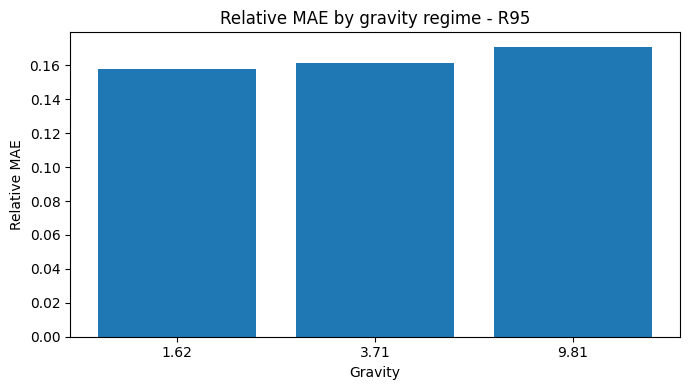

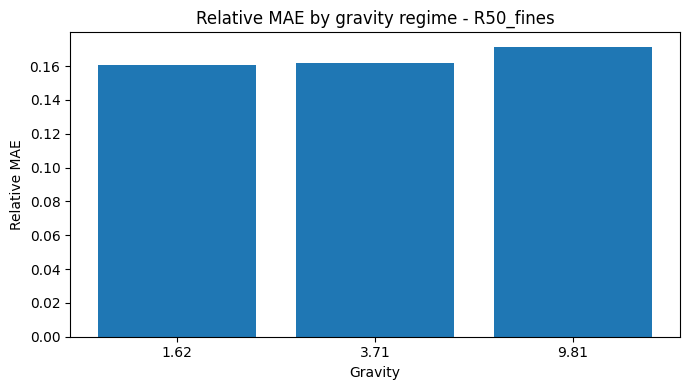

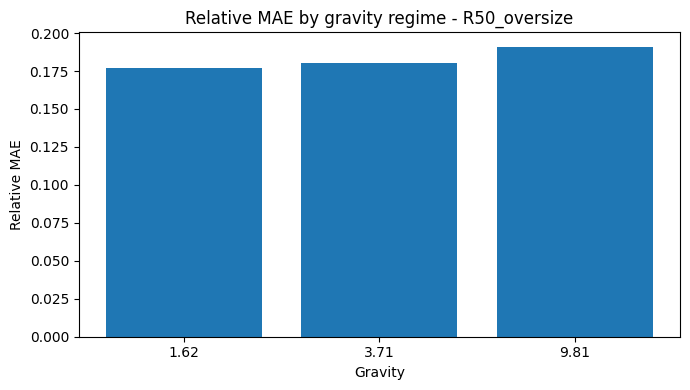

In [14]:
gravity_error_rows = []
for target in target_cols:
    abs_error = np.abs(selected_oof[target] - y[target])
    temp = pd.DataFrame({"gravity": raw_train["gravity"], "target": target, "abs_error": abs_error, "true_value": y[target], "prediction": selected_oof[target]})
    grouped = temp.groupby("gravity").agg(n=("abs_error", "size"), MAE=("abs_error", "mean"), Median_AE=("abs_error", "median"), true_mean=("true_value", "mean"), pred_mean=("prediction", "mean")).reset_index()
    grouped["relative_MAE"] = grouped["MAE"] / (grouped["true_mean"].abs() + 1e-9)
    grouped["target"] = target
    gravity_error_rows.append(grouped)
gravity_error_df = pd.concat(gravity_error_rows, ignore_index=True)
display(gravity_error_df)

for target in distance_targets:
    temp = gravity_error_df[gravity_error_df["target"] == target]
    plt.figure(figsize=(7, 4))
    plt.bar(temp["gravity"].astype(str), temp["relative_MAE"])
    plt.title(f"Relative MAE by gravity regime - {target}")
    plt.xlabel("Gravity")
    plt.ylabel("Relative MAE")
    plt.tight_layout()
    plt.show()

## 12. Constraint-Zone and Stress Validation

In [15]:
def evaluate_slice(mask, slice_name, y_true_df, y_pred_df):
    rows = []
    n = int(mask.sum())
    if n == 0:
        return pd.DataFrame([{"slice": slice_name, "n": 0}])
    for target in target_cols:
        yt = y_true_df.loc[mask, target]
        yp = y_pred_df.loc[mask, target]
        metrics = regression_metrics(yt, yp, target_name=target)
        metrics.update({"slice": slice_name, "n": n, "target": target, "bias": float((yp - yt).mean())})
        rows.append(metrics)
    return pd.DataFrame(rows)

q = raw_train.quantile([0.1, 0.9])
stress_masks = {
    "all_train": pd.Series(True, index=raw_train.index),
    "true_feasible_zone": feasibility_mask(y),
    "near_feasible_zone": near_feasible_mask(y),
    "low_gravity": raw_train["gravity"] == raw_train["gravity"].min(),
    "mid_gravity": raw_train["gravity"] == 3.71,
    "high_gravity": raw_train["gravity"] == raw_train["gravity"].max(),
    "high_energy_top10": raw_train["energy"] >= q.loc[0.9, "energy"],
    "high_coupling_top10": raw_train["coupling"] >= q.loc[0.9, "coupling"],
    "low_atmosphere_bottom10": raw_train["atmosphere"] <= q.loc[0.1, "atmosphere"],
    "high_atmosphere_top10": raw_train["atmosphere"] >= q.loc[0.9, "atmosphere"],
    "high_shape_factor_top10": raw_train["shape_factor"] >= q.loc[0.9, "shape_factor"],
}

stress_validation_df = pd.concat([evaluate_slice(mask, name, y, selected_oof) for name, mask in stress_masks.items()], ignore_index=True)
display(stress_validation_df.sort_values(["slice", "target"]))
display(pd.DataFrame([custom_constraint_metrics(y, selected_oof)]))

,MAE,RMSE,R2,normalized_MAE,slice,n,target,bias
0,7.711179,10.257217,0.975659,0.117271,all_train,2930,P80,-0.008502
4,50.250298,78.434966,0.899044,0.203526,all_train,2930,R50_fines,-0.309918
5,22.549196,38.438910,0.874300,0.207947,all_train,2930,R50_oversize,0.000712
3,40.488282,66.977968,0.921136,0.169732,all_train,2930,R95,-0.277394
1,0.006487,0.014240,0.956900,0.094558,all_train,2930,fines_frac,-0.000066
...,...,...,...,...,...,...,...,...
10,21.334611,27.622408,-0.091833,0.086410,true_feasible_zone,35,R50_fines,-0.354142
11,10.282803,13.125573,-0.118969,0.094827,true_feasible_zone,35,R50_oversize,0.068096
9,22.297445,28.670716,-0.138607,0.093473,true_feasible_zone,35,R95,-0.404398
7,0.010712,0.013224,-0.763178,0.156143,true_feasible_zone,35,fines_frac,0.002072


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,mean_pred_constraint_violation,median_pred_constraint_violation,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias
0,35,39,13,26,22,0.333333,0.371429,0.351351,199.85991,135.846149,372,4.571787,25.229399,14.175167


## 13. Train Final Models and Create Submission

In [16]:
submission_preds = pd.DataFrame(index=raw_test.index)
final_model_info = []

for target in target_cols:
    model_name, feature_set_name = best_model_feature_by_target[target]
    builder = AVAILABLE_MODELS[model_name]
    features = get_features_for_feature_set(feature_set_name, target)
    model = builder(random_state=123)
    model.fit(X_fe_train[features], y[target])
    pred = clip_predictions(model.predict(X_fe_test[features]), target)
    submission_preds[target] = pred
    final_model_info.append({"target": target, "model": model_name, "feature_set": feature_set_name, "n_features": len(features)})

final_model_info_df = pd.DataFrame(final_model_info)
display(final_model_info_df)

submission = pd.DataFrame({"scenario_id": np.arange(len(raw_test))})
for target in target_cols:
    submission[target] = submission_preds[target]

submission_path = SUBMISSIONS_DIR / "prediction_submission_boosting_controlled.csv"
submission.to_csv(submission_path, index=False)
print("Saved submission:", submission_path)
display(submission.head())
display(submission.describe().T)

,target,model,feature_set,n_features
0,P80,ExtraTrees,target_family_specific,34
1,fines_frac,ExtraTrees,target_family_specific,34
2,oversize_frac,CatBoost,extended_plus_regimes,48
3,R95,ExtraTrees,extended_plus_regimes,48
4,R50_fines,ExtraTrees,extended_plus_regimes,48
5,R50_oversize,ExtraTrees,extended_plus_regimes,48


Saved submission: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions/prediction_submission_boosting_controlled.csv


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,0,120.237928,0.110270,0.213630,692.796463,686.538356,299.046986
1,1,113.032326,0.049013,0.149596,207.431028,216.738510,101.653572
2,2,151.778252,0.101620,0.174032,778.520973,770.657539,339.048946
3,3,159.624954,0.010526,0.553186,492.214751,571.837443,259.738969
4,4,136.676394,0.044922,0.233055,198.465384,235.144984,98.394525


,count,mean,std,min,25%,50%,75%,max
scenario_id,492.0,245.500000,142.172431,0.000000,122.750000,245.500000,368.250000,491.000000
P80,492.0,154.482476,29.788987,78.210975,130.027597,152.530022,174.483822,220.248395
fines_frac,492.0,0.046959,0.050940,0.002141,0.007688,0.021027,0.078713,0.243272
oversize_frac,492.0,0.435297,0.213228,0.047251,0.248184,0.426876,0.625183,0.804170
R95,492.0,286.337887,227.681920,49.020449,110.817331,170.721602,465.817038,937.370944
R50_fines,492.0,324.335537,227.933850,63.907293,145.749692,207.093843,563.145656,835.322712
R50_oversize,492.0,141.807545,103.723524,27.318354,60.501547,87.715779,248.424089,406.996534


## 14. Feasibility Diagnostic on Test Predictions

In [17]:
test_pred_feasible = feasibility_mask(submission[target_cols])
test_violation = constraint_violation_score(submission[target_cols])
print("Predicted feasible test rows:", int(test_pred_feasible.sum()))
print("Mean predicted constraint violation:", float(test_violation.mean()))
print("Median predicted constraint violation:", float(np.median(test_violation)))

feasible_test_candidates = submission.loc[test_pred_feasible].copy()
feasible_test_candidates["constraint_violation"] = test_violation.loc[test_pred_feasible]
feasible_test_candidates["p80_distance_to_center"] = (feasible_test_candidates["P80"] - ((p80_min + p80_max) / 2)).abs()
display(feasible_test_candidates.sort_values(["constraint_violation", "p80_distance_to_center"]).head(20))

Predicted feasible test rows: 2
Mean predicted constraint violation: 198.04774959061058
Median predicted constraint violation: 94.25593989332418


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize,constraint_violation,p80_distance_to_center
156,156,98.442414,0.133221,0.106371,108.953094,98.918954,43.787521,0.0,0.057586
276,276,96.718151,0.174207,0.050150,161.352223,162.331295,70.996952,0.0,1.781849


## 15. Summary Questions

After running the notebook, summarize:

1. Which model wins for each target?
2. Does boosting improve `R95`, `R50_fines`, and `R50_oversize` compared with ExtraTrees?
3. Does feasibility precision/recall improve?
4. Are near-zone errors acceptable for inverse design?
5. Are errors still high in extreme gravity or high-energy slices?
6. Should the next step be hyperparameter tuning, ensemble averaging, or inverse design sampling?